# 電腦數學符號運算

# 解直角三角形實作

![](http://mail.mbc.edu.mo/mathsymImg/MATHS_2_2_trigonometricratios.png)    

Adjacent 邻近的  
Opposite 对面的   
Hypotenuse 斜边的     

$H^2=A^2+O^2$  

sin $\theta$ = $\frac{opp}{hyp}$   
cos $\theta$ = $\frac{adj}{hyp}$  
tan $\theta$ = $\frac{opp}{adj}$    

x 隨機數 (2,3,4,5,6,7,8)  
基於經典直角三角型.給出 theta, gamma, A, O, H 值.   
角 theta gamma 90度角   
邊 A O H

题型1：
給出兩條邊長度.  
求: 正弦,餘弦,正切的特殊銳角的三角函數值    
例题	答案式样	数型及范围	评分标准	时限  
1. sin(theta) = A/C  
2. cose(theta) =  A/H  

题型2：
給出一條邊長度,一角.  
利用正弦,餘弦,正切的特殊銳角的三角函數值 
求: 另一邊長度.   
例题	答案式样	数型及范围	评分标准	时限  
1. sin(theta) * C= A  
2. cose(theta) * H =  A  

參考希臘字母表:  
$\alpha$  \alpha    $A$	 A   
$\beta$	\beta   $B$	B   
$\gamma$	\gammma  $\Gamma$	\Gamma  
$\pi$	\pi   $\Pi$	\Pi  
$\phi$	\phi  $\Phi$	\Phi   
$\varphi$	\varphi  
$\theta$	\theta  

## 三角函數

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

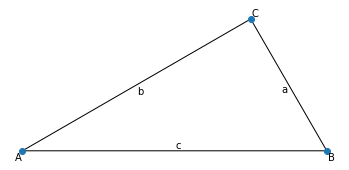

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

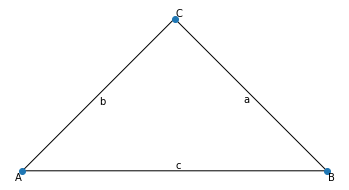

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

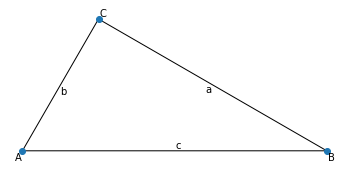

勾3,股4,弦5 直角三⻆型:


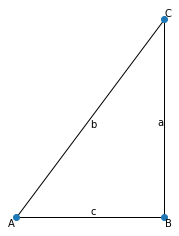

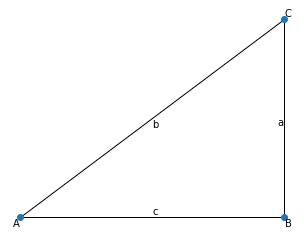

In [39]:
# Perquisites
import datetime
import numpy as np
import scipy as scp
import sympy as sp
from sympy.geometry import Point, Circle, Triangle, Segment, Line
import random
import math
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import Latex,HTML,Markdown                 #網頁顯示數學符號

def plotTriangle(t):
    A, B, C = t.vertices #頂点
    AB, BC, CA = Segment(A, B), Segment(B, C), Segment(C, A) #辺の設定 右辺は ABC.sidesと同等
    a, b, c = BC.length, CA.length, AB.length #辺の長さ
    opposides = { #頂点に対する対辺(opposite side)
        A: BC,
        B: CA,
        C: AB
    } #print(AB,BC,CA)#  print(*t.sides)    
    
    plt.close('all')
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.set_aspect('equal')
    #ax.grid()
    ax.set_axis_off() #軸の非表示
    ax.add_patch(plt.Polygon(t.vertices, fill=False))
    #ax.plot(*zip(*t.vertices), 'ro')
    ax.plot(*zip(*t.vertices), 'o')
    plt.text(*A, '$\mathrm{A}$', ha='right', va='top')
    plt.text(*B, '$\mathrm{B}$', ha='left', va='top')
    plt.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
    
    plt.text(*BC.midpoint, '$\mathrm{a}$', ha='right', va='top')
    plt.text(*CA.midpoint, '$\mathrm{b}$', ha='left', va='top')
    plt.text(*AB.midpoint, '$\mathrm{c}$', ha='left', va='bottom')    
    
    plt.show()
#特殊角 30,45,60
Degrees=[30,45,60] 
for d in Degrees:
    display(Latex(f"當 $\\theta={d}^o$, 求 $sin\\theta$ or  $cos\\theta$ or  $tan\\theta$ ?"))
    sv=sp.sin(sp.S(d)/180* sp.pi)
    cv=sp.cos(sp.S(d)/180* sp.pi)
    tv=sp.tan(sp.S(d)/180* sp.pi)
    display(Latex( r"$%s$, $%s$, $%s$"  % (sp.latex(sv),  sp.latex(cv),sp.latex(tv))))
    
    s1=random.choice([2,3,4,5,6])
    s2=cv*s1
    display(Latex( r"a=$%s$, o=$%s$, h=$%s$"  % (sp.latex(s1),sp.latex(s1*tv),sp.latex(s2))))
    t = Triangle(sas=(s2, d , s1))
    plotTriangle(t)
    
print("勾3,股4,弦5 直角三⻆型:")
t = Triangle(sss=(3, 4 , 5))
plotTriangle(t)

t = Triangle(sss=(4, 3 , 5))
plotTriangle(t)


## 源碼

In [ ]:
# Perquisites 
import datetime
import numpy as np
import scipy as scp
import sympy as sp
import random
import math
import matplotlib.pyplot as plt
from IPython.display import Latex,HTML,Markdown                 #網頁顯示數學符號
from matplotlib.figure import Figure
def GetKey():
    return ""
def GetTE(Qid, St, Val, Tx=0):
    ''' 單條題目記錄: St題目, Val電腦答案, Ans作答,OK檢查1/0, Tip提示'''
    TE = {}
    #TE["Key"] =r"%s.%s"% (datetime.datetime.now().isoformat().replace(":","_"),random.random())
    TE["Id"] = Qid
    TE["Tx"] = Tx
    TE["St"] = St
    TE["Val"] = Val
    TE["Ans"] = ""
    TE["OK"] = 0
    TE["Mark"] = 0
    TE["Minute"]= datetime.datetime.now().strftime("%M:%S")   #"%m-%d-%Y %H:%M:%S")
    TE["Tip"] = ""
    TE["PotImg"]=None
    return TE
def Plot_RightTriangle(A,O,H,Path_):
    try:
        # Triangle 1
        a=A.evalf()
        o=O.evalf()
        h=H.evalf()
        x=np.array([0,a,a,0])
        y=np.array([0,0,o,0])
        # for jupyternote
        plt.close('all')
        fig1=plt.figure(1)
        ax1=fig1.add_subplot(111)
        # Figure and Axes for WebSite
        #fig1=Figure()
        #fig1.set_figheight(3)
        #fig1.set_figwidth(3)
        #ax1=fig1.subplots()
        ax1.axis('square')
        ax1.plot(x,y)
        # Axes Limits
        
        ax1.set_xlim([-1,int(a)+2])
        ax1.set_ylim([-1,int(o)+2])
        ax1.text(0.5,0.25,'θ')
        
        ax1.text(a-0.5,0.25,'90')
        
        ax1.text(a-0.25,o-0.35,'γ')
        ax1.text(a/2,-0.5,f'a=${sp.latex(A)}$')
        ax1.text(a+0.5,o/2,f'b=${sp.latex(O)}$')
        #ax1.text(A/2-1,O/2,f'c=${sp.latex(H)}$')
        ax1.text(a/2-1,o/2,f'c')
        #fig1.savefig(os.getcwd()+"\\static\\"+Path_)
        plt.show()
        return Path_
    except Exception as e:
        print(e)
        return None

def Plot_RightTriangle2(A,O,H,r,Path_):
    try:
        #plt.close('all')
        # Triangle 1
        a=A.evalf()
        o=O.evalf()
        h=H.evalf()
        x=np.array([0,a,a,0])
        y=np.array([0,0,o,0])
        # Figure and Axes
        #fig1=Figure()
        #fig1.set_figheight(3)
        #fig1.set_figwidth(3)
        #ax1=fig1.subplots()
        
        # for jupyternote
        plt.close('all')
        fig1=plt.figure(1)
        ax1=fig1.add_subplot(111)
        # end for jupyternote
        
        ax1.axis('square')
        ax1.plot(x,y)
        # Axes Limits
        ax1.set_xlim([-1,int(a)+2])
        ax1.set_ylim([-1,int(o)+2])
        
        ax1.text(0.5,0.25,'θ')
        ax1.text(a-0.5,0.25,'90')
        ax1.text(a-0.35,o-0.4,f'γ(${r}^o$)')
        ax1.text(a/2,-0.5,f'a=${sp.latex(A)}$')
        #ax1.text(A+0.5,O/2,f'b={O}')
        ax1.text(a+0.5,o/2,f'b')
        #ax1.text(A/2-1,O/2,f'c=${sp.latex(H)}$')
        ax1.text(a/2-1,o/2,f'c')
        #fig1.savefig(os.getcwd()+"\\static\\"+Path_)
        
        # for jupyternote
        plt.show()
        # end for jupyternote
        return Path_
    except Exception as e:
        print(e)
        return None
        
    
def Get_PF306_Expr(QN,Tx=-1):
    NTE = []
    for Qid in range(0, QN):
        x=random.choice([2,3,4,5])
        if Tx == 1:
            theta = random.choice([30,45,60])
            gamma=90-theta
            if theta==30:
                A=x*sp.sqrt(3)
                O=sp.S(x)
                H=sp.S(2*x)
            elif theta==45:
                A=sp.S(x)
                O=sp.S(x)
                H=x*sp.sqrt(2)
            elif theta==60:
                A=sp.S(x)
                O=x*sp.sqrt(3)
                H=sp.S(2*x)
            bian_=["b","c"]
            bian=random.choice(bian_)
            St=["設直角三角形:", r"a=%s, \gamma=%s^o, 求 %s  = ?"%(sp.latex(A),gamma, bian)]
            Val = 1
            if bian=="b":
                Val=O
            if bian=="c":
                Val=H
            TE = GetTE(Qid, St, Val, Tx)
            TE["PlotImg"]=Plot_RightTriangle2(A,O,H,gamma,"img"+GetKey()+str(Qid)+".png")
            NTE.append(TE)
            
        else:
            theta = random.choice([30,45,60,37,53])
            gamma=90-theta
            if theta==30:
                A=x*sp.sqrt(3)
                O=sp.S(x)
                H=sp.S(2*x)
            elif theta==45:
                A=sp.S(x)
                O=sp.S(x)
                H=x*sp.sqrt(2)
            elif theta==60:
                A=sp.S(x)
                O=x*sp.sqrt(3)
                H=sp.S(2*x)
            elif theta==37:
                A=sp.S(4*x)
                O=sp.S(3*x)
                H=sp.S(5*x)
            elif theta==53:
                A=sp.S(3*x)
                O=sp.S(4*x)
                H=sp.S(5*x)        
            #A=random.choice([2,3,4,5,7])
            #O=random.choice([2,3,4,5,7])
            #H=sp.sqrt(A**2+O**2)
            angle_=["theta","gamma"]
            trig_=["sin","cos","tan"]
            trig=random.choice(trig_)
            ang=random.choice(angle_)
            St=["設直角三角形:", r"a=%s, b=%s, 求 %s \%s = ?"%(A,O, trig,ang)]
            Val = 1
            if trig=="sin":
                if ang=="theta":             
                    Val=O/H
                if ang=="gamma":             
                    Val=A/H
            if trig=="cos":
                if ang=="theta":             
                    Val=A/H
                if ang=="gamma":             
                    Val=O/H
            if trig=="tan":
                if ang=="theta":             
                    Val=sp.S(O)/A
                if ang=="gamma":             
                    Val=sp.S(A)/O
            
            TE = GetTE(Qid, St, Val, Tx)

            TE["PlotImg"]=Plot_RightTriangle(A,O,H,"img"+GetKey()+str(Qid)+".png")
            NTE.append(TE)

    return NTE

Get_PF306_Expr(10,Tx=0)
Get_PF306_Expr(10,Tx=1)


# Plot 圖

## 三邊 SSS

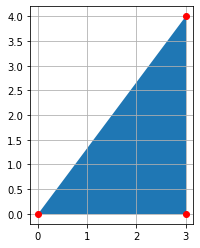

In [19]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.grid()

t = Triangle(sss=(3, 4, 5))

ax.add_patch(plt.Polygon(t.vertices))
ax.plot(*zip(*t.vertices), 'ro')

plt.show()

## 二邊一角 SAS

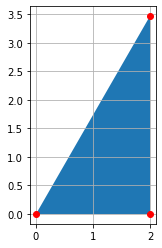

In [20]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.grid()

t = Triangle(sas=(4, 60, 2))

ax.add_patch(plt.Polygon(t.vertices))
ax.plot(*zip(*t.vertices), 'ro')

plt.show()

## 二角一邊 ASA , 及反轉

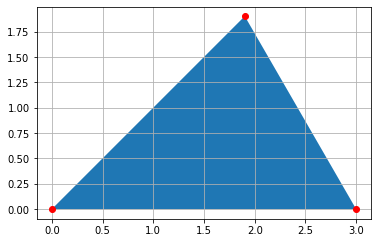

In [21]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.grid()

t = Triangle(asa=(45, 3, 60))

ax.add_patch(plt.Polygon(t.vertices))
ax.plot(*zip(*t.vertices), 'ro')

plt.show()


## 填色

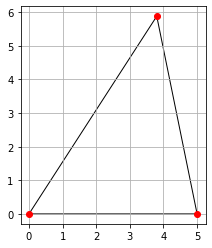

In [22]:
from sympy import pi

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.grid()

t = Triangle(sss=(5, 6, 7))

ax.add_patch(plt.Polygon(t.vertices, fill=False))
ax.plot(*zip(*t.vertices), 'ro')

plt.show()

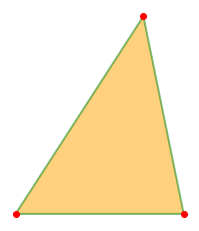

In [26]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off() #軸の非表示

t = Triangle(sss=(5, 6, 7))

ax.add_patch(plt.Polygon(t.vertices,
                         facecolor="orange", #塗り潰しの色
                         linewidth=2, #辺の長さ
                         edgecolor="green", #辺の色
                         alpha=.5 #半透明 0=透明 1=不透明
                        ))
ax.plot(*zip(*t.vertices), 'ro')

plt.show()

## 變數

In [30]:
ABC = Triangle(sss=(5, 6, 7))
A, B, C = ABC.vertices #頂点
AB, BC, CA = Segment(A, B), Segment(B, C), Segment(C, A) #辺の設定 右辺は ABC.sidesと同等
a, b, c = BC.length, CA.length, AB.length #辺の長さ
opposides = { #頂点に対する対辺(opposite side)
    A: BC,
    B: CA,
    C: AB
}
print(AB,BC,CA)
print(*ABC.sides)

Segment2D(Point2D(0, 0), Point2D(5, 0)) Segment2D(Point2D(5, 0), Point2D(19/5, 12*sqrt(6)/5)) Segment2D(Point2D(19/5, 12*sqrt(6)/5), Point2D(0, 0))
Segment2D(Point2D(0, 0), Point2D(5, 0)) Segment2D(Point2D(5, 0), Point2D(19/5, 12*sqrt(6)/5)) Segment2D(Point2D(19/5, 12*sqrt(6)/5), Point2D(0, 0))


## 中點

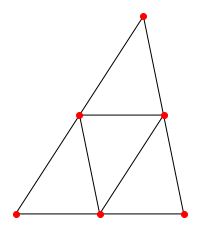

In [31]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()

ax.add_patch(plt.Polygon((A,B,C), fill=False))
ax.plot(*zip(A,B,C), 'ro')

ax.add_patch(plt.Polygon((BC.midpoint,CA.midpoint,AB.midpoint), fill=False))
ax.plot(*zip(BC.midpoint,CA.midpoint,AB.midpoint), 'ro')

plt.show()

## 文字

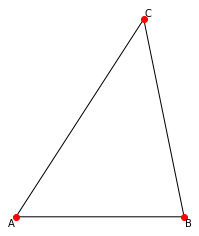

In [32]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()

ax.add_patch(plt.Polygon((A, B, C), fill=False))
ax.plot(*zip(*t.vertices), 'ro')

plt.text(*A, '$\mathrm{A}$', ha='right', va='top')
plt.text(*B, '$\mathrm{B}$', ha='left', va='top')
plt.text(*C, '$\mathrm{C}$', ha='left', va='bottom')

plt.show()

In [33]:
ABC = Triangle(sss=(5, 6, 7))
A, B, C = ABC.vertices #頂点
AB, BC, CA = Segment(A, B), Segment(B, C), Segment(C, A) #辺の設定 右辺は ABC.sidesと同等
a, b, c = BC.length, CA.length, AB.length #辺の長さ
opposides = { #頂点に対する対辺(opposite side)
    A: BC,
    B: CA,
    C: AB
}

## 重心點

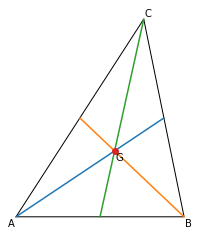

In [34]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()

ax.add_patch(plt.Polygon((A, B, C), fill=False))

G = ABC.centroid #重心を取得
ax.plot(*zip(A, BC.midpoint)) #AとBCの中点を結ぶ
ax.plot(*zip(B, CA.midpoint)) #BとCAの中点を結ぶ
ax.plot(*zip(C, AB.midpoint)) #CとABの中点を結ぶ
ax.plot(*zip(G), 'o') #重心をプロット

plt.text(*A, '$\mathrm{A}$', ha='right', va='top')
plt.text(*B, '$\mathrm{B}$', ha='left', va='top')
plt.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
plt.text(*G, '$\mathrm{G}$', ha='left', va='top')

plt.show()

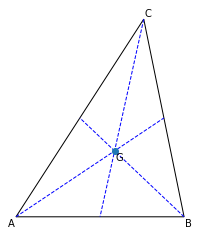

In [35]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()

ax.add_patch(plt.Polygon((A, B, C), fill=False))

G = ABC.centroid #重心を取得
for X in [A, B, C]: #中線のプロット
    ax.plot(*zip(X, opposides[X].midpoint), linestyle='--', color='blue', linewidth=1)
ax.plot(*zip(G), 'o') #重心をプロット

ax.text(*A, '$\mathrm{A}$', ha='right', va='top')
ax.text(*B, '$\mathrm{B}$', ha='left', va='top')
ax.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
ax.text(*G, '$\mathrm{G}$', ha='left', va='top')

plt.show()

## 重心公式

In [36]:
ABC=Triangle(sss=(5,6,7))
A, B, C = ABC.vertices
G = (A+B+C)/3 #重心を計算
G == ABC.centroid

True

## 垂心

In [37]:
alts = ABC.altitudes #垂線の取得
alts

{Point2D(0, 0): Segment2D(Point2D(0, 0), Point2D(24/5, 2*sqrt(6)/5)),
 Point2D(5, 0): Segment2D(Point2D(5, 0), Point2D(361/245, 228*sqrt(6)/245)),
 Point2D(19/5, 12*sqrt(6)/5): Segment2D(Point2D(19/5, 12*sqrt(6)/5), Point2D(19/5, 0))}

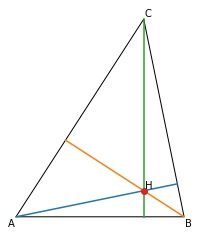

In [38]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()
ax.add_patch(plt.Polygon((A, B, C), fill=False))

H=ABC.orthocenter #垂心の取得
alts = ABC.altitudes #垂線の取得
for X in [A, B, C]: #垂線のプロット
    ax.plot(*zip(*alts[X].args))
ax.plot(*zip(H), 'o') #垂心をプロット

plt.text(*A, '$\mathrm{A}$', ha='right', va='top')
plt.text(*B, '$\mathrm{B}$', ha='left', va='top')
plt.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
plt.text(*H, '$\mathrm{H}$', ha='left', va='bottom')

plt.show()

## 中點垂直

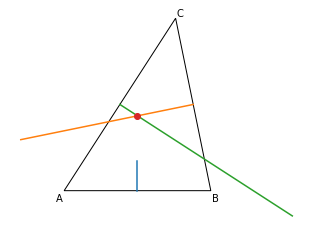

In [39]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()

ax.add_patch(plt.Polygon((A, B, C), fill=False))

ax.plot(*zip(*AB.perpendicular_bisector().args)) #ABの垂直二等分線をプロット？
ax.plot(*zip(*BC.perpendicular_bisector().args)) #BCの垂直二等分線をプロット？
ax.plot(*zip(*CA.perpendicular_bisector().args)) #CAの垂直二等分線をプロット？
ax.plot(*ABC.circumcenter, 'o') #外心をプロット

ax.text(*A, '$\mathrm{A}$', ha='right', va='top')
ax.text(*B, '$\mathrm{B}$', ha='left', va='top')
ax.text(*C, '$\mathrm{C}$', ha='left', va='bottom')

plt.show()

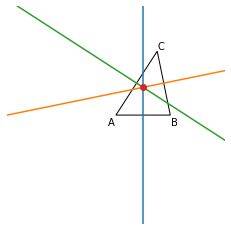

In [42]:
def side_of_line(p, q, mint=-100, maxt=100):
    return zip(p+(q-p)*mint, p+(q-p)*maxt)

def side_of_ray(p, q, maxt=100):
    return zip(p, p+(q-p)*maxt)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

ax.add_patch(plt.Polygon((A, B, C), fill=False))

ax.plot(*side_of_line(*AB.perpendicular_bisector().args)) #ABの垂直二等分線をプロット
ax.plot(*side_of_line(*BC.perpendicular_bisector().args)) #BCの垂直二等分線をプロット
ax.plot(*side_of_line(*CA.perpendicular_bisector().args)) #CAの垂直二等分線をプロット

ax.plot(*ABC.circumcenter, 'o') #外心

ax.text(*A, '$\mathrm{A}$', ha='right', va='top')
ax.text(*B, '$\mathrm{B}$', ha='left', va='top')
ax.text(*C, '$\mathrm{C}$', ha='left', va='bottom')

plt.show()

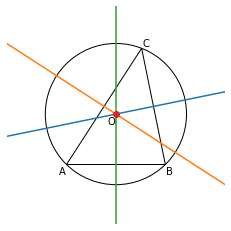

In [44]:

ax = plt.gca()
ax.set_xlim((-3,8))
ax.set_ylim((-3,8))
ax.set_axis_off()
ax.set_aspect('equal')

ax.add_patch(plt.Polygon((A, B, C), fill=False))

O=ABC.circumcenter #外心の取得

for X in [A, B, C]:
    ax.plot(*side_of_line(*opposides[X].perpendicular_bisector().args)) #Xの対辺の垂直二等分線をプロット

ax.plot(*O, 'o') #外心をプロット
ax.add_patch(plt.Circle(O, ABC.circumradius, fill=False)) #外接円をプロット

ax.text(*A, '$\mathrm{A}$', ha='right', va='top')
ax.text(*B, '$\mathrm{B}$', ha='left', va='top')
ax.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
ax.text(*O, '$\mathrm{O}$', ha='right', va='top')

plt.show()

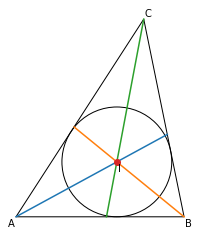

In [43]:
ax = plt.gca()
ax.set_axis_off()
ax.set_aspect('equal')

ax.add_patch(plt.Polygon((A, B, C), fill=False))

bisectors = ABC.bisectors() #内角の二等分線を取得

I = ABC.incenter #内心の取得
for X in [A, B, C]:
    ax.plot(*zip(*bisectors[X].args)) #角Xの二等分線をプロット
ax.plot(*zip(I), 'o') #内心をプロット
ax.add_patch(plt.Circle(I, ABC.inradius, fill=False)) #内接円をプロット

ax.text(*A, '$\mathrm{A}$', ha='right', va='top')
ax.text(*B, '$\mathrm{B}$', ha='left', va='top')
ax.text(*C, '$\mathrm{C}$', ha='left', va='bottom')
ax.text(*I, '$\mathrm{I}$', ha='left', va='top')

plt.show()

# Reference

[Symbolic Algebra and Geometry Introduction](https://coolum001.github.io/category/sympy.html)    

[sympyとmatplotlibで三角形](https://qiita.com/HigashinoSola/items/2ab8894b543e0c55cfa7)

[sin-cos-and-tan](https://revisionmaths.com/gcse-maths-revision/trigonometry/sin-cos-and-tan)

[Sine And Cosine Rule](http://www.bat400.com/step-up/sect4/index.htm)     

[Sine, Cosine and Tangent](https://www.mathsisfun.com/sine-cosine-tangent.html)  